# Notebook 02: Preprocessing & Tokenization

**Project:** Intelligent Code Review Assistant  
**Notebook:** 02 of 04  
**Input:** `../data/processed/labeled_dataset_full.csv`  
**Output:** `../data/processed/train.pt`, `val.pt`, `test.pt` (PyTorch tensors)

---

## Objectives
- Load and validate the labeled dataset from Notebook 01
- Clean and normalize raw code text
- Tokenize using CodeBERT's tokenizer (WordPiece, max 512 tokens)
- Handle class imbalance — compute class weights for training
- Split into train / validation / test sets (stratified)
- Build a PyTorch Dataset class ready for the model
- Save tokenized splits to disk for Notebook 03

---

## Pipeline
```
labeled_dataset_full.csv
        ↓
Load & Validate
        ↓
Text Cleaning & Normalization
        ↓
CodeBERT Tokenization (truncate/pad to 512)
        ↓
Stratified Train / Val / Test Split (70/15/15)
        ↓
PyTorch Dataset & DataLoader
        ↓
Save -> data/processed/train.pt / val.pt / test.pt
```

### Install dependencies

In [1]:
# Install libraries needed for this notebook.
# Run once, then restart kernel if transformers/torch were not already installed.

# !pip install transformers torch scikit-learn pandas numpy tqdm matplotlib -q

---
## Section 1: Imports & Configuration

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import warnings
import pickle
warnings.filterwarnings("ignore")

# ── Data handling ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── PyTorch ────────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace Transformers ───────────────────────────────────────────────────
from transformers import AutoTokenizer

# ── Scikit-learn ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Progress bar ───────────────────────────────────────────────────────────────
from tqdm.notebook import tqdm

# ── Styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ── Central config — change values here, they propagate everywhere ─────────────
#
# MODEL_NAME   : HuggingFace model ID for the tokenizer.
#                'microsoft/codebert-base' is pre-trained on Python, Java, Go etc.
#                It uses a WordPiece tokenizer with a vocabulary of 50,265 tokens.
#
# MAX_LENGTH   : Max number of tokens per sample after tokenization.
#                CodeBERT's transformer has a hard limit of 512 — do not exceed.
#                Sequences longer than this are TRUNCATED (end is cut off).
#
# TEST_SIZE    : Fraction of data held out for final evaluation (never seen during training).
# VAL_SIZE     : Fraction of remaining data used for validation during training.
#
# RANDOM_STATE : Fixed seed — ensures the same split every time run this notebook.
#
# BATCH_SIZE   : Number of samples per training batch.
#                16 fits comfortably in 8GB GPU RAM with CodeBERT.
#                Use 8 if you get CUDA out-of-memory errors.

CONFIG = {
    "MODEL_NAME"   : "microsoft/codebert-base",
    "MAX_LENGTH"   : 512,
    "TEST_SIZE"    : 0.15,
    "VAL_SIZE"     : 0.15,
    "RANDOM_STATE" : 42,
    "BATCH_SIZE"   : 16,
    "DATA_PATH"    : "../data/processed/labeled_dataset_full.csv",
    "SAVE_DIR"     : "../data/processed/",
}

# ── Detect device ──────────────────────────────────────────────────────────────
# Uses GPU (CUDA) if available, otherwise falls back to CPU.
# Training on CPU is very slow for CodeBERT — use Google Colab or Kaggle if needed.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG["DEVICE"] = str(DEVICE)

print("Configuration set:")
for k, v in CONFIG.items():
    print(f"   {k:<15}: {v}")
print(f"\n   Device: {DEVICE}")
if str(DEVICE) == "cpu":
    print("  No GPU detected. Training will be slow.")
    print("  Consider using Google Colab (Runtime → Change runtime type → GPU).")

Configuration set:
   MODEL_NAME     : microsoft/codebert-base
   MAX_LENGTH     : 512
   TEST_SIZE      : 0.15
   VAL_SIZE       : 0.15
   RANDOM_STATE   : 42
   BATCH_SIZE     : 16
   DATA_PATH      : ../data/processed/labeled_dataset_full.csv
   SAVE_DIR       : ../data/processed/
   DEVICE         : cpu

   Device: cpu
  No GPU detected. Training will be slow.
  Consider using Google Colab (Runtime → Change runtime type → GPU).


---
## Section 2: Load & Validate Dataset

Load the combined labeled dataset saved by Notebook 01 and perform
sanity checks before any processing begins.

In [4]:
# Load the full labeled dataset produced by Notebook 01.
# Labeled_dataset_full.csv (Python + C) is used because the Python-only
# file had very few buggy samples (the GitHub scraper yield was low).
# CodeBERT was pre-trained on multiple languages including C so this is fine.

print(f"Loading: {CONFIG['DATA_PATH']}")
df = pd.read_csv(CONFIG["DATA_PATH"])

print(f"\nLoaded successfully.")
print(f"   Shape  : {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Loading: ../data/processed/labeled_dataset_full.csv

Loaded successfully.
   Shape  : (39656, 11)
   Columns: ['code', 'docstring', 'repo', 'language', 'label', 'source', 'id', 'code_length', 'line_count', 'word_count', 'has_docstring']

First 3 rows:


,code,docstring,repo,language,label,source,id,code_length,line_count,word_count,has_docstring
0,def __msgc_step3_discontinuity_localization(se...,Estimate discontinuity in basis of low resolut...,mjirik/imcut,python,0,codesearchnet,0,2091,50,156,True
1,"def __multiscale_gc_lo2hi_run(self): # , pyed...",Run Graph-Cut segmentation with refinement of ...,mjirik/imcut,python,0,codesearchnet,1,3165,81,227,True
2,"def __multiscale_gc_hi2lo_run(self): # , pyed...",Run Graph-Cut segmentation with simplifiyng of...,mjirik/imcut,python,0,codesearchnet,2,906,19,79,True


### Validate dataset

In [5]:
# Run validation checks before processing.
# If any check fails, go back to Notebook 01 and fix the issue there.

print("Running validation checks...\n")

checks_passed = True

# Check 1: Required columns exist
required_cols = ["code", "label", "language", "source"]
for col in required_cols:
    if col not in df.columns:
        print(f"Missing column: '{col}'")
        checks_passed = False
    else:
        print(f" Column '{col}' exists")

# Check 2: No missing values in code or label
null_code  = df["code"].isna().sum()
null_label = df["label"].isna().sum()
print(f"\n{'✅' if null_code  == 0 else '❌'}  Null code values  : {null_code}")
print(f"{'✅' if null_label == 0 else '❌'}  Null label values : {null_label}")

# Check 3: Labels are only 0 and 1
unique_labels = sorted(df["label"].unique())
label_ok = set(unique_labels) == {0, 1}
print(f"\n{'✅' if label_ok else '❌'}  Label values: {unique_labels}  (expected [0, 1])")

# Check 4: Label dtype is integer
dtype_ok = df["label"].dtype in ["int32", "int64"]
print(f"{'✅' if dtype_ok else '❌'}  Label dtype : {df['label'].dtype}  (expected int)")

# Check 5: No empty code strings
empty_code = (df["code"].str.strip().str.len() == 0).sum()
print(f"\n{'✅' if empty_code == 0 else '❌'}  Empty code strings: {empty_code}")

# Summary
print(f"\n{'✅ All checks passed.' if checks_passed else '❌ Fix issues above before continuing.'}")

# Auto-fix label dtype if needed
if not dtype_ok:
    df["label"] = df["label"].astype(int)
    print("   Auto-fixed: label column cast to int.")

Running validation checks...

 Column 'code' exists
 Column 'label' exists
 Column 'language' exists
 Column 'source' exists

✅  Null code values  : 0
✅  Null label values : 0

✅  Label values: [np.int64(0), np.int64(1)]  (expected [0, 1])
✅  Label dtype : int64  (expected int)

✅  Empty code strings: 0

✅ All checks passed.


### Dataset overview

In [6]:
# Quick statistical overview of the loaded dataset.

print("Label distribution:")
print(df["label"].value_counts().to_string())

print("\nLanguage distribution:")
print(df["language"].value_counts().to_string())

print("\nSource distribution:")
print(df["source"].value_counts().to_string())

clean = (df["label"] == 0).sum()
buggy = (df["label"] == 1).sum()
ratio = clean / buggy
print(f"\nClass imbalance ratio (clean:buggy) = {ratio:.2f}:1")
print("This ratio will be used to compute class weights for the loss function.")

Label distribution:
label
0    28372
1    11284

Language distribution:
language
c         24956
python    14700

Source distribution:
source
devign           24956
codesearchnet    14694
github_prs           6

Class imbalance ratio (clean:buggy) = 2.51:1
This ratio will be used to compute class weights for the loss function.


---
## Section 3: Text Cleaning & Normalization

Raw code from GitHub diffs and CSN contains noise that can hurt tokenization:
- Excessive blank lines from diff extraction
- Non-UTF-8 characters
- Null bytes and control characters
- Extremely long whitespace runs

Minimal cleaning is applied — we do NOT remove comments or rename variables
because CodeBERT was trained on raw source code and handles them naturally.
Over-cleaning (e.g. stripping all strings) can actually reduce model accuracy.

### Cleaning function

In [7]:
def clean_code(code: str) -> str:
    """
    Lightly clean a raw code string.

    Steps applied in order:
    1. Decode/encode to remove non-UTF-8 bytes that would crash the tokenizer
    2. Remove null bytes (\\x00) — common in binary-adjacent C code
    3. Normalize line endings (Windows \\r\\n -> Unix \\n)
    4. Collapse 3+ consecutive blank lines into 2
       (CodeBERT treats blank lines as context; too many add noise)
    5. Strip leading/trailing whitespace from the whole snippet
    6. Enforce a character length cap — extremely long strings are truncated
       BEFORE tokenization (the tokenizer will also truncate, but this
       avoids memory spikes from trying to tokenize 50K-char strings)

    Deliberately do NOT:
    - Remove comments (they contain useful semantic info for bug detection)
    - Strip string literals (they may contain patterns related to bugs)
    - Rename identifiers (would destroy CodeBERT's sub-word alignment)
    """
    if not isinstance(code, str):
        return ""

    # Step 1: Remove non-UTF-8 bytes
    code = code.encode("utf-8", errors="ignore").decode("utf-8", errors="ignore")

    # Step 2: Remove null bytes
    code = code.replace("\x00", "")

    # Step 3: Normalize line endings
    code = code.replace("\r\n", "\n").replace("\r", "\n")

    # Step 4: Collapse 3+ consecutive blank lines → 2 blank lines
    code = re.sub(r"\n{3,}", "\n\n", code)

    # Step 5: Strip leading/trailing whitespace
    code = code.strip()

    # Step 6: Cap at 5000 characters to avoid tokenizer memory spikes
    # (CodeBERT will further truncate to 512 tokens during tokenization)
    code = code[:5000]

    return code


# Test the function on a sample
sample_raw = "def foo():\n\n\n\n\n    x = 1\r\n    return x\x00"
sample_clean = clean_code(sample_raw)
print("Raw    :", repr(sample_raw[:80]))
print("Cleaned:", repr(sample_clean[:80]))
print("\nCleaning function defined.")

Raw    : 'def foo():\n\n\n\n\n    x = 1\r\n    return x\x00'
Cleaned: 'def foo():\n\n    x = 1\n    return x'

Cleaning function defined.


### Apply cleaning

In [8]:
# Apply cleaning to every row in the dataset.
# tqdm shows a progress bar so you can see it running.

print("Cleaning code strings...")
tqdm.pandas(desc="Cleaning")

df["code_clean"] = df["code"].progress_apply(clean_code)

# Drop any rows that became empty after cleaning
before = len(df)
df = df[df["code_clean"].str.strip().str.len() > 0].reset_index(drop=True)
removed = before - len(df)

print(f"\nCleaning complete.")
print(f"   Rows before : {before:,}")
print(f"   Rows removed (became empty): {removed:,}")
print(f"   Rows after  : {len(df):,}")

# Spot-check: compare raw vs clean for one sample
idx = 0
print(f"\n--- Raw sample [{idx}] (first 200 chars) ---")
print(df["code"].iloc[idx][:200])
print(f"\n--- Cleaned sample [{idx}] (first 200 chars) ---")
print(df["code_clean"].iloc[idx][:200])

Cleaning code strings...


Cleaning:   0%|          | 0/39656 [00:00<?, ?it/s]


Cleaning complete.
   Rows before : 39,656
   Rows removed (became empty): 0
   Rows after  : 39,656

--- Raw sample [0] (first 200 chars) ---
def __msgc_step3_discontinuity_localization(self):
        """
        Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution
        ""

--- Cleaned sample [0] (first 200 chars) ---
def __msgc_step3_discontinuity_localization(self):
        """
        Estimate discontinuity in basis of low resolution image segmentation.
        :return: discontinuity in low resolution
        ""


---
## Section 4: Load CodeBERT Tokenizer

CodeBERT (`microsoft/codebert-base`) uses a **RoBERTa-style WordPiece tokenizer**:
- Vocabulary size: 50,265 tokens
- Special tokens: `<s>` (CLS), `</s>` (SEP), `<pad>`, `<unk>`, `<mask>`
- Trained on code from 6 languages: Python, Java, JavaScript, PHP, Ruby, Go

For classification, every input is formatted as:

<s> [code tokens] </s>

The `<s>` (CLS) token's final hidden state is used as the sequence representation
that feeds into the classification head.

###  Load tokenizer

In [9]:
# Download and load the CodeBERT tokenizer.
# On first run this downloads ~500KB from HuggingFace and caches it.
# Subsequent runs load from cache instantly.

print(f"Loading tokenizer: {CONFIG['MODEL_NAME']}")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_NAME"])

print(f"\nTokenizer loaded.")
print(f"   Vocabulary size : {tokenizer.vocab_size:,}")
print(f"   Model max length: {tokenizer.model_max_length}")
print(f"   Special tokens  : {tokenizer.all_special_tokens}")

Loading tokenizer: microsoft/codebert-base


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]


Tokenizer loaded.
   Vocabulary size : 50,265
   Model max length: 512
   Special tokens  : ['<s>', '</s>', '<unk>', '<pad>', '<mask>']


### Tokenizer exploration

In [10]:
# Understand how the tokenizer processes code before applying it to the full dataset.
# This cell is purely exploratory — it does not modify any data.

example_code = """
def calculate_average(numbers):
    total = sum(numbers)
    return total / len(numbers)   # potential ZeroDivisionError bug
"""

# Tokenize without padding/truncation to see the raw output
tokens = tokenizer.tokenize(example_code)
encoded = tokenizer(example_code, return_tensors="pt")

print(f"Example code:")
print(example_code)
print(f"\nNumber of tokens     : {len(tokens)}")
print(f"Token IDs shape      : {encoded['input_ids'].shape}")
print(f"\nFirst 20 tokens:")
print(tokens[:20])
print(f"\nCorresponding IDs:")
print(encoded['input_ids'][0][:20].tolist())

Example code:

def calculate_average(numbers):
    total = sum(numbers)
    return total / len(numbers)   # potential ZeroDivisionError bug


Number of tokens     : 42
Token IDs shape      : torch.Size([1, 44])

First 20 tokens:
['Ċ', 'def', 'Ġcalculate', '_', 'average', '(', 'n', 'umbers', '):', 'Ċ', 'Ġ', 'Ġ', 'Ġ', 'Ġtotal', 'Ġ=', 'Ġsum', '(', 'n', 'umbers', ')']

Corresponding IDs:
[0, 50118, 9232, 15756, 1215, 20365, 1640, 282, 30806, 3256, 50118, 1437, 1437, 1437, 746, 5457, 6797, 1640, 282, 30806]


### Token length analysis

Analyzing token lengths on a sample of 2,000 rows...


Tokenizing sample:   0%|          | 0/2000 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2006 > 512). Running this sequence through the model will result in indexing errors



Token length statistics:
   Min    : 19
   Max    : 3293
   Mean   : 542.6
   Median : 352.0
   P90    : 1270.6
   P95    : 1711.3

Samples that fit within 512 tokens: 1,279 / 2,000 (63.9%)


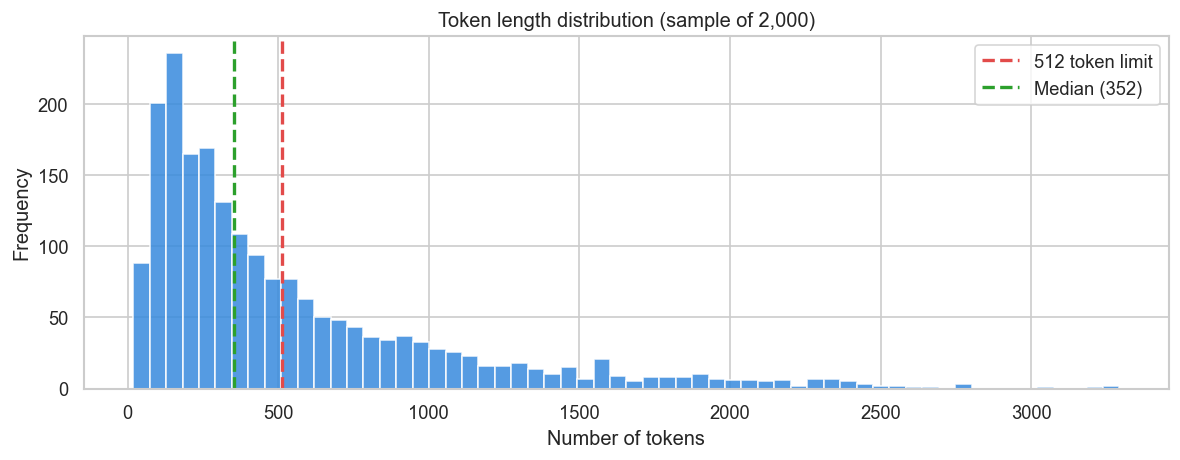

In [11]:
# Analyze the distribution of token lengths BEFORE truncation.
# This tells us how much information is lost by truncating to 512 tokens.
# 2000 rows are sampled to keep this fast.

print("Analyzing token lengths on a sample of 2,000 rows...")

sample_df = df.sample(min(2000, len(df)), random_state=CONFIG["RANDOM_STATE"])

token_lengths = []
for code in tqdm(sample_df["code_clean"], desc="Tokenizing sample"):
    ids = tokenizer.encode(code, add_special_tokens=True)
    token_lengths.append(len(ids))

token_lengths = np.array(token_lengths)

print(f"\nToken length statistics:")
print(f"   Min    : {token_lengths.min()}")
print(f"   Max    : {token_lengths.max()}")
print(f"   Mean   : {token_lengths.mean():.1f}")
print(f"   Median : {np.median(token_lengths):.1f}")
print(f"   P90    : {np.percentile(token_lengths, 90):.1f}")
print(f"   P95    : {np.percentile(token_lengths, 95):.1f}")
print(f"\nSamples that fit within 512 tokens: "
      f"{(token_lengths <= 512).sum():,} / {len(token_lengths):,} "
      f"({(token_lengths <= 512).mean()*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=60, color="#378ADD", edgecolor="white", alpha=0.85)
ax.axvline(512, color="#E24B4A", linewidth=2, linestyle="--", label="512 token limit")
ax.axvline(np.median(token_lengths), color="#2CA02C", linewidth=2,
           linestyle="--", label=f"Median ({np.median(token_lengths):.0f})")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("Frequency")
ax.set_title("Token length distribution (sample of 2,000)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/07_token_length_distribution.png", bbox_inches="tight")
plt.show()

---
## Section 5: Train / Validation / Test Split

The dataset is splitted **before tokenization** so that:
- No test/val data leaks into training
- The same split is reproducible (fixed random seed)
- Class proportions are preserved in each split (stratified split)

Split ratios:
| Split | Fraction | Purpose |
|---|---|---|
| Train | 70% | Model learns from this |
| Validation | 15% | Tune hyperparameters, early stopping |
| Test | 15% | Final evaluation — touch only once |

### Stratified split

In [12]:
# Split into train / val / test using stratified sampling.
# Stratified = each split has the same class ratio as the full dataset.
# This is important because we have class imbalance (2.5:1).

X = df["code_clean"].values    # input features (code text)
y = df["label"].values         # target labels (0 or 1)

# Step 1: Split off test set (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=CONFIG["TEST_SIZE"],
    stratify=y,                           # preserve class ratio
    random_state=CONFIG["RANDOM_STATE"]
)

# Step 2: Split remaining into train and val
# val_size is relative to the trainval portion, so we adjust it:
# we want 15% of total → 15/85 ≈ 0.176 of trainval
adjusted_val = CONFIG["VAL_SIZE"] / (1 - CONFIG["TEST_SIZE"])

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=adjusted_val,
    stratify=y_trainval,
    random_state=CONFIG["RANDOM_STATE"]
)

print("Dataset split complete.")
print(f"\n{'Split':<10} {'Total':>8} {'Clean (0)':>12} {'Buggy (1)':>12} {'Ratio':>8}")
print("─" * 52)
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    c = (y_split == 0).sum()
    b = (y_split == 1).sum()
    r = c / max(b, 1)
    print(f"{name:<10} {len(y_split):>8,} {c:>12,} {b:>12,} {r:>7.1f}:1")

print(f"\nTotal samples accounted for: {len(y_train)+len(y_val)+len(y_test):,} / {len(df):,}")

Dataset split complete.

Split         Total    Clean (0)    Buggy (1)    Ratio
────────────────────────────────────────────────────
Train        27,758       19,860        7,898     2.5:1
Val           5,949        4,256        1,693     2.5:1
Test          5,949        4,256        1,693     2.5:1

Total samples accounted for: 39,656 / 39,656


### Compute class weights

In [13]:
# Because clean code (0) outnumbers buggy code (1) by ~2.5:1,
# an unweighted model will learn to predict "clean" for everything
# and still get ~72% accuracy — a useless classifier.
#
# Solution: compute class weights and pass them to the loss function.
# The weight for each class = total_samples / (n_classes * class_count).
# The minority class (buggy) gets a HIGHER weight -> model penalized more
# for missing bugs than for false positives.

classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train                  # computed from TRAIN only — not val or test
)

# Convert to a PyTorch tensor for use in training
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print("Class weights computed from training set:")
print(f"   Weight for class 0 (clean) : {class_weights[0]:.4f}")
print(f"   Weight for class 1 (buggy) : {class_weights[1]:.4f}")
print(f"\n   PyTorch tensor: {class_weights_tensor}")
print(f"\n   Interpretation: every buggy sample counts {class_weights[1]/class_weights[0]:.1f}x "
      f"more than a clean sample during loss computation.")

# Save weights for use in Notebook 03
np.save("../data/processed/class_weights.npy", class_weights)
print(f"\nSaved -> ../data/processed/class_weights.npy")

Class weights computed from training set:
   Weight for class 0 (clean) : 0.6988
   Weight for class 1 (buggy) : 1.7573

   PyTorch tensor: tensor([0.6988, 1.7573])

   Interpretation: every buggy sample counts 2.5x more than a clean sample during loss computation.

Saved -> ../data/processed/class_weights.npy


---
## Section 6: Tokenization

Now all three splits are tokenized using CodeBERT's tokenizer.

Key tokenizer arguments:
| Argument | Value | Reason |
|---|---|---|
| `max_length` | 512 | CodeBERT's max input size |
| `padding` | `'max_length'` | Pad shorter sequences to 512 with `<pad>` tokens |
| `truncation` | `True` | Cut sequences longer than 512 from the end |
| `return_attention_mask` | `True` | 1 for real tokens, 0 for padding — model ignores padded positions |
| `return_tensors` | `None` | Return Python lists (we batch-encode and convert later) |

The tokenizer output for each sample is a dict with:
- `input_ids` — integer IDs for each token (list of 512 ints)
- `attention_mask` — 1/0 mask indicating real vs padded positions (list of 512 ints)

### Batch tokenize function

In [14]:
def batch_tokenize(texts, tokenizer, max_length, batch_size=512, desc="Tokenizing"):
    """
    Tokenize a list of code strings in batches.

    Processing in batches (default 512 at a time) is much faster than
    tokenizing one sample at a time because the tokenizer can vectorize
    operations across the batch.

    Parameters
    ----------
    texts      : list or array of code strings
    tokenizer  : loaded HuggingFace tokenizer
    max_length : maximum token length (sequences are padded/truncated to this)
    batch_size : number of samples to tokenize at once
    desc       : label shown on the progress bar

    Returns
    -------
    dict with keys 'input_ids' and 'attention_mask', each a list of lists
    """
    all_input_ids      = []
    all_attention_mask = []

    texts = list(texts)    # ensure it's a list

    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[i : i + batch_size]

        encoded = tokenizer(
            batch,
            max_length=max_length,
            padding="max_length",       # pad to exactly max_length tokens
            truncation=True,            # cut sequences longer than max_length
            return_attention_mask=True, # 1 for real tokens, 0 for padding
            return_tensors=None         # return Python lists, not tensors
        )

        all_input_ids.extend(encoded["input_ids"])
        all_attention_mask.extend(encoded["attention_mask"])

    return {
        "input_ids":      all_input_ids,
        "attention_mask": all_attention_mask
    }


print("Batch tokenize function defined.")

Batch tokenize function defined.


### Tokenize train split

In [15]:
# Tokenize the training set.
# With 27K+ samples this takes 2–5 minutes on CPU.

print(f"Tokenizing TRAIN split ({len(X_train):,} samples)...")

train_encodings = batch_tokenize(
    texts=X_train,
    tokenizer=tokenizer,
    max_length=CONFIG["MAX_LENGTH"],
    desc="Train"
)

print(f"\nTrain tokenization complete.")
print(f"   input_ids shape    : {len(train_encodings['input_ids'])} × {len(train_encodings['input_ids'][0])}")
print(f"   attention_mask shape: {len(train_encodings['attention_mask'])} × {len(train_encodings['attention_mask'][0])}")

Tokenizing TRAIN split (27,758 samples)...


Train:   0%|          | 0/55 [00:00<?, ?it/s]


Train tokenization complete.
   input_ids shape    : 27758 × 512
   attention_mask shape: 27758 × 512


### Tokenize val and test splits

In [16]:
# Tokenize the validation and test sets.

print(f"Tokenizing VAL split ({len(X_val):,} samples)...")
val_encodings = batch_tokenize(
    texts=X_val,
    tokenizer=tokenizer,
    max_length=CONFIG["MAX_LENGTH"],
    desc="Val"
)

print(f"\nTokenizing TEST split ({len(X_test):,} samples)...")
test_encodings = batch_tokenize(
    texts=X_test,
    tokenizer=tokenizer,
    max_length=CONFIG["MAX_LENGTH"],
    desc="Test"
)

print(f"\nVal and Test tokenization complete.")
print(f"   Val  samples: {len(val_encodings['input_ids']):,}")
print(f"   Test samples: {len(test_encodings['input_ids']):,}")

Tokenizing VAL split (5,949 samples)...


Val:   0%|          | 0/12 [00:00<?, ?it/s]


Tokenizing TEST split (5,949 samples)...


Test:   0%|          | 0/12 [00:00<?, ?it/s]


Val and Test tokenization complete.
   Val  samples: 5,949
   Test samples: 5,949


### Verify a tokenized sample

In [17]:
# Manually inspect one tokenized sample to confirm the output looks correct.
# This is a quick sanity check — always do this after tokenization.

idx = 0    # index of sample to inspect

input_ids = train_encodings["input_ids"][idx]
attn_mask = train_encodings["attention_mask"][idx]

print(f"Sample index: {idx}")
print(f"Label       : {y_train[idx]}  ({'buggy' if y_train[idx]==1 else 'clean'})")
print(f"\nOriginal code (first 200 chars):")
print(X_train[idx][:200])

print(f"\nToken IDs (first 20):  {input_ids[:20]}")
print(f"Attention mask (first 20): {attn_mask[:20]}")
print(f"\nTotal tokens (including padding): {len(input_ids)}")

# Count real tokens vs padding tokens
real_tokens = sum(attn_mask)
pad_tokens  = len(attn_mask) - real_tokens
print(f"Real tokens    : {real_tokens}")
print(f"Padding tokens : {pad_tokens}")

# Decode back to text to verify round-trip
decoded = tokenizer.decode(input_ids, skip_special_tokens=True)
print(f"\nDecoded (first 200 chars):")
print(decoded[:200])

Sample index: 0
Label       : 0  (clean)

Original code (first 200 chars):
static int h263_probe(AVProbeData *p)

{

    int code;

    const uint8_t *d;

    if (p->buf_size < 6)

        return 0;

    d = p->buf;

    code = (d[0] << 14) | (d[1] << 6) | (d[2] >> 2);

    

Token IDs (first 20):  [0, 42653, 6979, 1368, 29969, 1215, 4892, 1610, 1640, 10612, 10653, 1610, 30383, 1009, 642, 43, 50118, 50118, 45152, 50140]
Attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Total tokens (including padding): 512
Real tokens    : 145
Padding tokens : 367

Decoded (first 200 chars):
static int h263_probe(AVProbeData *p)

{

    int code;

    const uint8_t *d;

    if (p->buf_size < 6)

        return 0;

    d = p->buf;

    code = (d[0] << 14) | (d[1] << 6) | (d[2] >> 2);

    


---
## Section 7: PyTorch Dataset Class

PyTorch models consume data through `Dataset` and `DataLoader` objects.

- `Dataset`: wraps the data, returns one sample at a time via `__getitem__`
- `DataLoader`: batches samples, shuffles training data, handles multi-worker loading

`CodeDataset` class stores the tokenized `input_ids`, `attention_mask`,
and `labels` as PyTorch tensors and serves them to the training loop.

### CodeDataset class

In [18]:
class CodeDataset(Dataset):
    """
    PyTorch Dataset for tokenized code classification.

    Stores input_ids, attention_mask, and labels as tensors.
    Returns one sample as a dict when indexed.

    Parameters
    ----------
    encodings : dict with keys 'input_ids' and 'attention_mask'
                (output of batch_tokenize)
    labels    : array-like of integer labels (0 or 1)
    """

    def __init__(self, encodings: dict, labels):
        # Convert to tensors once at construction time.
        # torch.long (int64) is required by nn.Embedding and CrossEntropyLoss.
        self.input_ids      = torch.tensor(encodings["input_ids"],      dtype=torch.long)
        self.attention_mask = torch.tensor(encodings["attention_mask"],  dtype=torch.long)
        self.labels         = torch.tensor(list(labels),                 dtype=torch.long)

    def __len__(self):
        # Called by DataLoader to know the total number of samples.
        return len(self.labels)

    def __getitem__(self, idx):
        # Called by DataLoader for each sample in a batch.
        # Returns a dict — this format works directly with HuggingFace models.
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels":         self.labels[idx]
        }

    def get_label_distribution(self):
        """Utility: show class counts in this split."""
        labels = self.labels.numpy()
        unique, counts = np.unique(labels, return_counts=True)
        return dict(zip(unique, counts))


print("CodeDataset class defined.")

CodeDataset class defined.


### Build Dataset objects

In [19]:
# Instantiate Dataset objects for each split.

train_dataset = CodeDataset(train_encodings, y_train)
val_dataset   = CodeDataset(val_encodings,   y_val)
test_dataset  = CodeDataset(test_encodings,  y_test)

print("Dataset objects created.")
print(f"\n{'Split':<10} {'Samples':>10} {'Clean (0)':>12} {'Buggy (1)':>12}")
print("─" * 46)
for name, ds in [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]:
    dist = ds.get_label_distribution()
    clean = dist.get(0, 0)
    buggy = dist.get(1, 0)
    print(f"{name:<10} {len(ds):>10,} {clean:>12,} {buggy:>12,}")

# Verify one item shape
sample_item = train_dataset[0]
print(f"\nSample item keys  : {list(sample_item.keys())}")
print(f"input_ids shape   : {sample_item['input_ids'].shape}")
print(f"attention_mask shape: {sample_item['attention_mask'].shape}")
print(f"label             : {sample_item['labels'].item()}")

Dataset objects created.

Split         Samples    Clean (0)    Buggy (1)
──────────────────────────────────────────────
Train          27,758       19,860        7,898
Val             5,949        4,256        1,693
Test            5,949        4,256        1,693

Sample item keys  : ['input_ids', 'attention_mask', 'labels']
input_ids shape   : torch.Size([512])
attention_mask shape: torch.Size([512])
label             : 0


### Build DataLoaders

In [20]:
# DataLoaders wrap Datasets and handle:
# - Batching: groups samples into batches of BATCH_SIZE
# - Shuffling: randomizes order each epoch (train only — never shuffle val/test)
# - num_workers: parallel data loading (set to 0 on Windows to avoid issues)

NUM_WORKERS = 0    # Use 0 on Windows; safe on Linux/Mac too for small datasets

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,              # shuffle training data every epoch
    num_workers=NUM_WORKERS,
    pin_memory=(str(DEVICE) == "cuda")  # faster GPU transfer if using CUDA
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,             # never shuffle val/test — order doesn't matter
    num_workers=NUM_WORKERS,
    pin_memory=(str(DEVICE) == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(str(DEVICE) == "cuda")
)

print("DataLoaders created.")
print(f"\n{'Split':<10} {'Samples':>10} {'Batches':>10} {'Batch size':>12}")
print("─" * 44)
for name, loader in [("Train", train_loader), ("Val", val_loader), ("Test", test_loader)]:
    print(f"{name:<10} {len(loader.dataset):>10,} {len(loader):>10,} {CONFIG['BATCH_SIZE']:>12}")

# Verify one batch shape
batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"   input_ids      : {batch['input_ids'].shape}")
print(f"   attention_mask : {batch['attention_mask'].shape}")
print(f"   labels         : {batch['labels'].shape}")

DataLoaders created.

Split         Samples    Batches   Batch size
────────────────────────────────────────────
Train          27,758      1,735           16
Val             5,949        372           16
Test            5,949        372           16

Sample batch shapes:
   input_ids      : torch.Size([16, 512])
   attention_mask : torch.Size([16, 512])
   labels         : torch.Size([16])


---
## Section 8: Visualization — Tokenization Quality Checks

Before saving, The tokenized data is vizualized to confirm:
1. Padding distribution across splits
2. Token utilization (how much of the 512-token window is used)
3. Class balance in each split

### Plot: Real token distribution per split

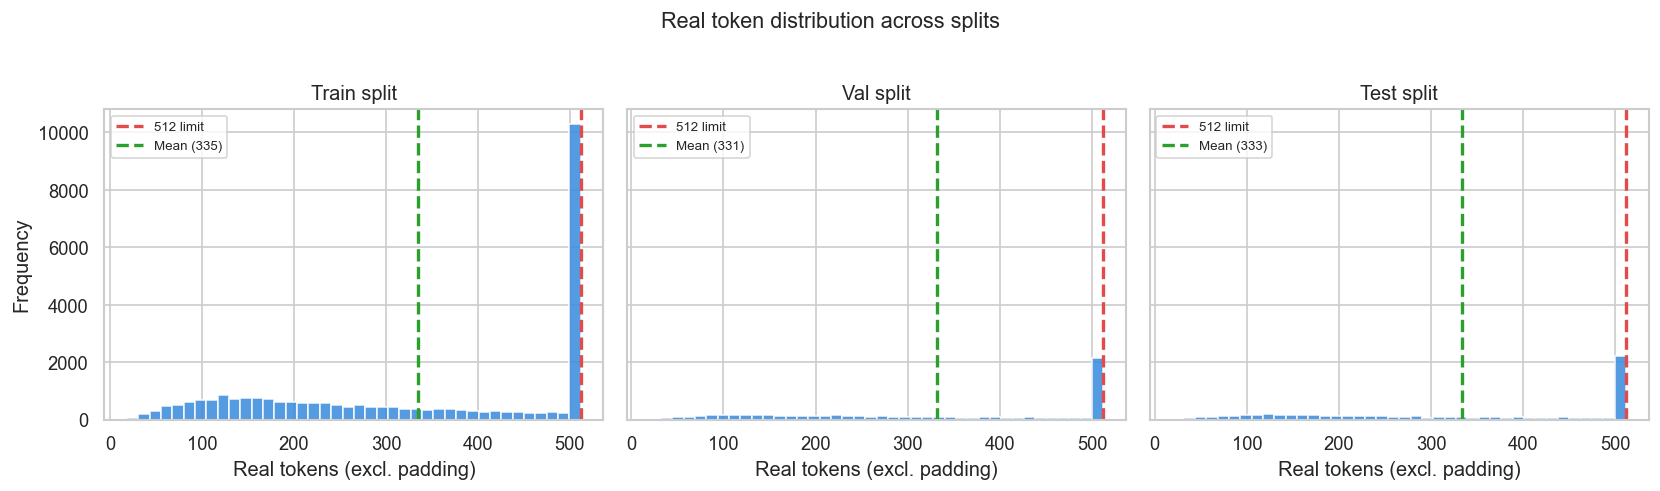

In [21]:
# Compare how much of the 512-token window is actually used (vs padding)
# across all three splits. This shows if our MAX_LENGTH of 512 is appropriate.

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (name, ds) in zip(axes, [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]):
    # Count real tokens per sample (attention_mask sum = real token count)
    real_tokens = ds.attention_mask.sum(dim=1).numpy()

    ax.hist(real_tokens, bins=40, color="#378ADD", edgecolor="white", alpha=0.85)
    ax.axvline(512, color="#E24B4A", linewidth=2, linestyle="--", label="512 limit")
    ax.axvline(real_tokens.mean(), color="#2CA02C", linewidth=2,
               linestyle="--", label=f"Mean ({real_tokens.mean():.0f})")
    ax.set_title(f"{name} split")
    ax.set_xlabel("Real tokens (excl. padding)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequency")
plt.suptitle("Real token distribution across splits", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/08_token_distribution_splits.png", bbox_inches="tight")
plt.show()

### Plot: Class balance per split

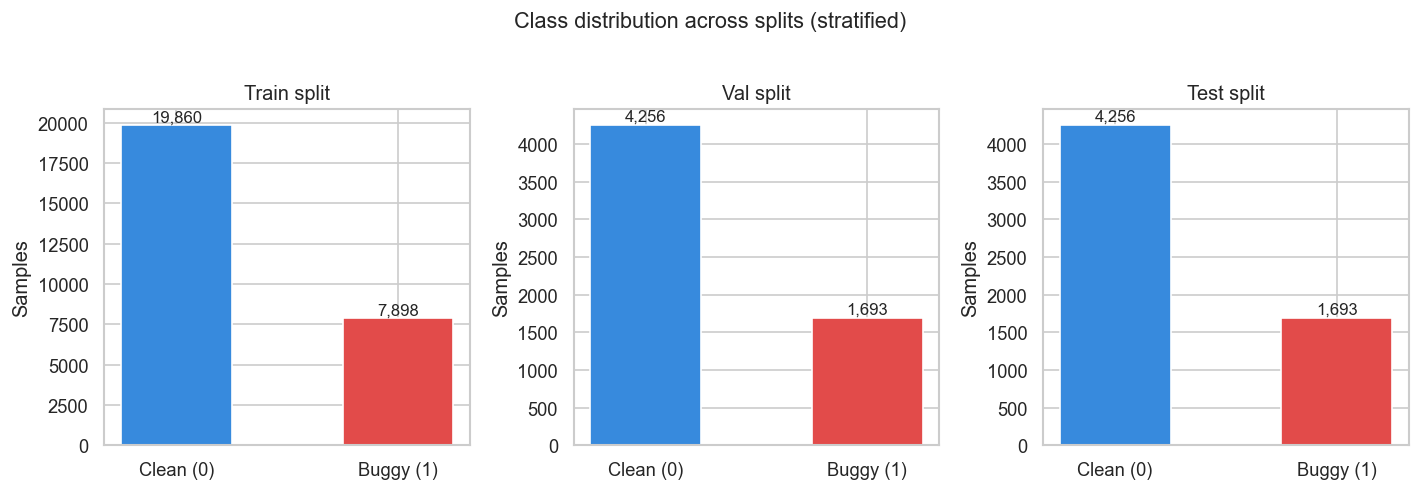

In [22]:
# Verify that stratified splitting preserved the class ratio in each split.

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ["#378ADD", "#E24B4A"]

for ax, (name, ds) in zip(axes, [("Train", train_dataset), ("Val", val_dataset), ("Test", test_dataset)]):
    dist  = ds.get_label_distribution()
    clean = dist.get(0, 0)
    buggy = dist.get(1, 0)

    bars = ax.bar(["Clean (0)", "Buggy (1)"], [clean, buggy], color=colors, width=0.5)
    ax.set_title(f"{name} split")
    ax.set_ylabel("Samples")

    for bar, val in zip(bars, [clean, buggy]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{val:,}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Class distribution across splits (stratified)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/09_class_balance_splits.png", bbox_inches="tight")
plt.show()

---
## Section 9: Save Processed Data

Save everything Notebook 03 needs:
- `train.pt` / `val.pt` / `test.pt` — PyTorch tensors (input_ids, attention_mask, labels)
- `class_weights.npy` — numpy array of class weights for weighted loss
- `preprocessing_config.pkl` — config dict so Notebook 03 uses identical settings

In [23]:
# Save each split as a .pt file (PyTorch serialized tensors).
# torch.save stores the entire Dataset object including all tensors.
# torch.load in Notebook 03 will restore it instantly without re-tokenizing.

save_dir = CONFIG["SAVE_DIR"]
os.makedirs(save_dir, exist_ok=True)

torch.save(train_dataset, os.path.join(save_dir, "train.pt"))
torch.save(val_dataset,   os.path.join(save_dir, "val.pt"))
torch.save(test_dataset,  os.path.join(save_dir, "test.pt"))

print("Datasets saved:")
for fname in ["train.pt", "val.pt", "test.pt"]:
    path = os.path.join(save_dir, fname)
    size_mb = os.path.getsize(path) / (1024**2)
    print(f"   {path:<45} {size_mb:>6.1f} MB")

Datasets saved:
   ../data/processed/train.pt                     217.1 MB
   ../data/processed/val.pt                        46.5 MB
   ../data/processed/test.pt                       46.5 MB


### Save config

In [25]:
# Save the preprocessing config so Notebook 03 loads the right tokenizer
# and uses identical settings without having to manually match values.

config_to_save = {
    "model_name"    : CONFIG["MODEL_NAME"],
    "max_length"    : CONFIG["MAX_LENGTH"],
    "batch_size"    : CONFIG["BATCH_SIZE"],
    "random_state"  : CONFIG["RANDOM_STATE"],
    "num_labels"    : 2,
    "train_size"    : len(train_dataset),
    "val_size"      : len(val_dataset),
    "test_size"     : len(test_dataset),
    "class_weights" : class_weights.tolist(),
    "label_map"     : {0: "clean", 1: "buggy"}
}

config_path = os.path.join(save_dir, "preprocessing_config.pkl")
with open(config_path, "wb") as f:
    pickle.dump(config_to_save, f)

print(f"Config saved -> {config_path}")
print(f"\nConfig contents:")
for k, v in config_to_save.items():
    print(f"   {k:<18}: {v}")

Config saved -> ../data/processed/preprocessing_config.pkl

Config contents:
   model_name        : microsoft/codebert-base
   max_length        : 512
   batch_size        : 16
   random_state      : 42
   num_labels        : 2
   train_size        : 27758
   val_size          : 5949
   test_size         : 5949
   class_weights     : [0.6988418932527694, 1.7572803241326918]
   label_map         : {0: 'clean', 1: 'buggy'}


### Final verification

In [26]:
# Load back each saved file to confirm they can be restored correctly.
# This catches corruption issues before Notebook 03 needs them.

print("Verifying saved files...\n")

# Load datasets
train_check = torch.load(os.path.join(save_dir, "train.pt"), weights_only=False)
val_check   = torch.load(os.path.join(save_dir, "val.pt"),   weights_only=False)
test_check  = torch.load(os.path.join(save_dir, "test.pt"),  weights_only=False)

print(f"train.pt  — {len(train_check):,} samples  "
      f"| input_ids: {train_check.input_ids.shape}")
print(f"val.pt    — {len(val_check):,} samples  "
      f"| input_ids: {val_check.input_ids.shape}")
print(f"test.pt   — {len(test_check):,} samples  "
      f"| input_ids: {test_check.input_ids.shape}")

# Load class weights
weights_check = np.load(os.path.join(save_dir, "class_weights.npy"))
print(f"\nclass_weights.npy — {weights_check}")

# Load config
with open(os.path.join(save_dir, "preprocessing_config.pkl"), "rb") as f:
    config_check = pickle.load(f)
print(f"\npreprocessing_config.pkl — keys: {list(config_check.keys())}")

print("\nAll files verified. Ready for Notebook 03.")

Verifying saved files...

train.pt  — 27,758 samples  | input_ids: torch.Size([27758, 512])
val.pt    — 5,949 samples  | input_ids: torch.Size([5949, 512])
test.pt   — 5,949 samples  | input_ids: torch.Size([5949, 512])

class_weights.npy — [0.69884189 1.75728032]

preprocessing_config.pkl — keys: ['model_name', 'max_length', 'batch_size', 'random_state', 'num_labels', 'train_size', 'val_size', 'test_size', 'class_weights', 'label_map']

All files verified. Ready for Notebook 03.


In [27]:
print("""
═════════════════════════════════════════════════════════
         NOTEBOOK 02 COMPLETE                            
═════════════════════════════════════════════════════════
  Next -> Notebook 03: Model Training                    
═════════════════════════════════════════════════════════
""")

print("Files saved to ../data/processed/:")
for f in ["train.pt", "val.pt", "test.pt", "class_weights.npy", "preprocessing_config.pkl"]:
    path = os.path.join(CONFIG["SAVE_DIR"], f)
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024**2)
        print(f" {f:<35} {size:.1f} MB")
    else:
        print(f" {f}  — NOT FOUND")

print()
print("Figures saved to ../reports/figures/:")
for f in ["07_token_length_distribution.png",
          "08_token_distribution_splits.png",
          "09_class_balance_splits.png"]:
    path = f"../reports/figures/{f}"
    status = "✅" if os.path.exists(path) else "❌"
    print(f"   {status}  {f}")


═════════════════════════════════════════════════════════
         NOTEBOOK 02 COMPLETE                            
═════════════════════════════════════════════════════════
  Next -> Notebook 03: Model Training                    
═════════════════════════════════════════════════════════

Files saved to ../data/processed/:
 train.pt                            217.1 MB
 val.pt                              46.5 MB
 test.pt                             46.5 MB
 class_weights.npy                   0.0 MB
 preprocessing_config.pkl            0.0 MB

Figures saved to ../reports/figures/:
   ✅  07_token_length_distribution.png
   ✅  08_token_distribution_splits.png
   ✅  09_class_balance_splits.png
